# EXP-02: Learn++ on MNIST Digits — Replicating the Original Paper

This notebook replicates the original Learn++ setup (Polikar et al., 2001) using MNIST handwritten digits.
The original paper used MLP for optical character recognition — this is the closest modern equivalent.

**Purpose**: Validate that our Learn++ implementation produces expected behavior on the dataset class
the algorithm was originally designed for (digit recognition).

**Comparison**: MLP (original paper) vs Decision Tree (Learn++.NSE, 2011)

**Batch design**: Incremental class introduction
- D₁: digits 0–3
- D₂: digits 4–6
- D₃: digits 7–9

In [1]:
import numpy as np
import time
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import balanced_accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [2]:
# --- Base learner factories (same as EXP-01) ---

def make_paper_learner():
    """MLP — original Learn++ base classifier (Polikar et al., 2001)."""
    return MLPClassifier(
        hidden_layer_sizes=(50,),
        max_iter=500,
        random_state=RANDOM_SEED
    )

def make_recommended_learner():
    """Decision Tree — from Learn++.NSE (Elwell & Polikar, 2011)."""
    return DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_SEED
    )

In [3]:
# --- Learn++ implementation (identical to notebook 01) ---

class LearnPP:
    """Learn++ incremental learning algorithm.
    
    Reference: Polikar, R., Upda, L., Upda, S.S., & Honavar, V. (2001).
    Learn++: An incremental learning algorithm for supervised neural networks.
    IEEE Transactions on Systems, Man, and Cybernetics.
    """
    
    def __init__(self, base_learner_factory, T_k=10, max_retries=3):
        self.base_learner_factory = base_learner_factory
        self.T_k = T_k
        self.max_retries = max_retries
        self.hypotheses = []
        self.betas = []
        self.classes_ = None
    
    def partial_fit(self, X, y):
        n_samples = len(X)
        if self.classes_ is None:
            self.classes_ = np.unique(y)
        else:
            self.classes_ = np.unique(np.concatenate([self.classes_, np.unique(y)]))
        
        w = np.ones(n_samples) / n_samples

        if len(self.hypotheses) > 0:
            H_init = self.predict(X)
            E_init = np.sum(w[H_init != y])
            E_init = np.clip(E_init, 1e-10, 1.0 - 1e-10)
            B_init = E_init / (1 - E_init)
            correct_init = (H_init == y).astype(float)
            w = w * (B_init ** correct_init)
            sum_w_init = np.sum(w)
            if sum_w_init < 1e-15:
                w = np.ones(n_samples) / n_samples
            else:
                w = w / sum_w_init
    
        for t in range(self.T_k):
            for retry in range(self.max_retries):
                sum_w = np.sum(w)
                if sum_w < 1e-15:
                    w = np.ones(n_samples) / n_samples
                    sum_w = 1.0
                D_t = w / sum_w

                indices = np.random.choice(n_samples, size=n_samples, replace=True, p=D_t)
                X_train, y_train = X[indices], y[indices]
                
                h_t = self.base_learner_factory()
                h_t.fit(X_train, y_train)
                
                predictions = h_t.predict(X)
                incorrect = (predictions != y).astype(float)
                epsilon_t = np.dot(D_t, incorrect)
                
                if epsilon_t < 0.5:
                    break
            else:
                continue
            
            beta_t = epsilon_t / (1 - epsilon_t + 1e-10)
            self.hypotheses.append(h_t)
            self.betas.append(beta_t)
            
            H_t_predictions = self.predict(X)
            incorrect_H_t = (H_t_predictions != y).astype(float)
            e_t = np.dot(D_t, incorrect_H_t)
            
            b_t = e_t / (1 - e_t + 1e-10)
            correct_H_t = (H_t_predictions == y).astype(float)
            w = w * (b_t ** correct_H_t)
            
            sum_w_new = np.sum(w)
            if sum_w_new < 1e-15:
                w = np.ones(n_samples) / n_samples
            else:
                w = w / sum_w_new
    
    def predict(self, X):
        if not self.hypotheses:
            raise RuntimeError("No hypotheses trained yet. Call partial_fit first.")
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        votes = np.zeros((n_samples, n_classes))
        
        for h_t, beta_t in zip(self.hypotheses, self.betas):
            vote_weight = np.log(1.0 / (beta_t + 1e-10))
            predictions = h_t.predict(X)
            for i, pred in enumerate(predictions):
                class_idx = np.where(self.classes_ == pred)[0]
                if len(class_idx) > 0:
                    votes[i, class_idx[0]] += vote_weight
        
        return self.classes_[np.argmax(votes, axis=1)]

In [4]:
# --- Load MNIST digits ---
import gzip, struct, os
from pathlib import Path
from urllib.request import urlretrieve

def load_mnist_digits(data_dir="data/mnist_digits"):
    """Download original MNIST digits from GitHub mirror."""
    base_url = "https://github.com/golbin/TensorFlow-MNIST/raw/master/mnist/data/"
    files = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "test_images":  "t10k-images-idx3-ubyte.gz",
        "test_labels":  "t10k-labels-idx1-ubyte.gz",
    }
    Path(data_dir).mkdir(parents=True, exist_ok=True)
    
    for name, fname in files.items():
        fpath = os.path.join(data_dir, fname)
        if not os.path.exists(fpath):
            print(f"  Downloading {fname}...")
            urlretrieve(base_url + fname, fpath)
    
    def read_images(path):
        with gzip.open(path, 'rb') as f:
            _, n, rows, cols = struct.unpack('>IIII', f.read(16))
            return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
    
    def read_labels(path):
        with gzip.open(path, 'rb') as f:
            struct.unpack('>II', f.read(8))
            return np.frombuffer(f.read(), dtype=np.uint8)
    
    X_train = read_images(os.path.join(data_dir, files["train_images"]))
    y_train = read_labels(os.path.join(data_dir, files["train_labels"]))
    X_test = read_images(os.path.join(data_dir, files["test_images"]))
    y_test = read_labels(os.path.join(data_dir, files["test_labels"]))
    return X_train, y_train, X_test, y_test

print("Loading MNIST digits...")
X_train_raw, y_train_raw, X_test_raw, y_test_raw = load_mnist_digits()

X_mnist = np.vstack([X_train_raw, X_test_raw]) / 255.0
y_mnist = np.hstack([y_train_raw, y_test_raw]).astype(int)

print(f"Dataset: MNIST Digits")
print(f"Shape: {X_mnist.shape}")
print(f"Classes: {np.unique(y_mnist)}")
print(f"Samples per class: {[np.sum(y_mnist == c) for c in range(10)]}")

Loading MNIST digits...
Dataset: MNIST Digits
Shape: (70000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]
Samples per class: [np.int64(6903), np.int64(7877), np.int64(6990), np.int64(7141), np.int64(6824), np.int64(6313), np.int64(6876), np.int64(7293), np.int64(6825), np.int64(6958)]


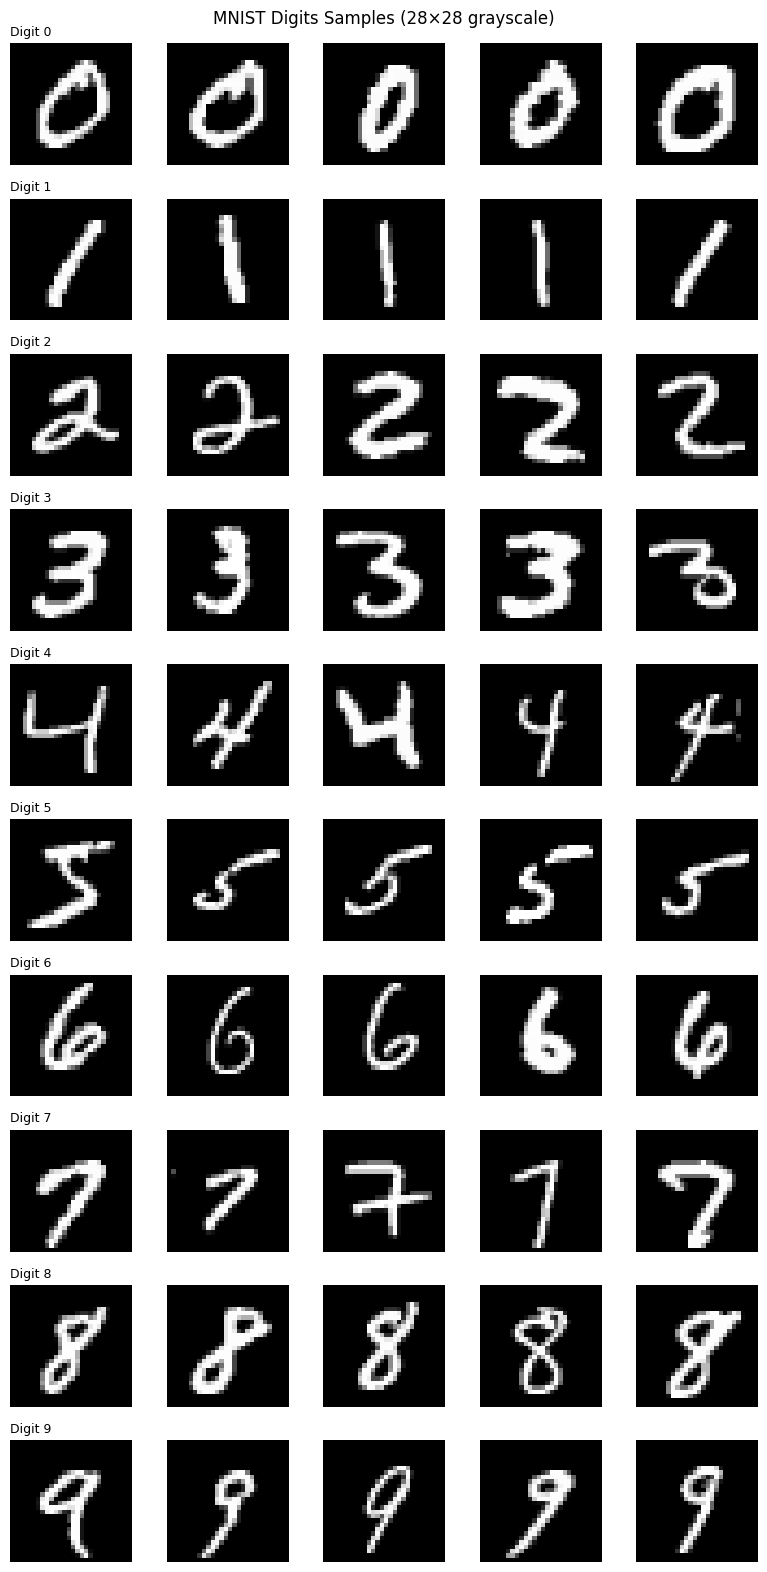


Saved to: data\mnist_digits\sample_images
Files:
  class_0_digit_0.png
  class_1_digit_1.png
  class_2_digit_2.png
  class_3_digit_3.png
  class_4_digit_4.png
  class_5_digit_5.png
  class_6_digit_6.png
  class_7_digit_7.png
  class_8_digit_8.png
  class_9_digit_9.png
  mnist_digits_grid.png


In [13]:
# --- Save sample MNIST Digits images as viewable PNGs ---
from pathlib import Path

digit_class_names = [str(i) for i in range(10)]

out_dir = Path("data/mnist_digits/sample_images")
out_dir.mkdir(parents=True, exist_ok=True)

# Save a grid: 5 examples per class (10 classes × 5 = 50 images in one figure)
fig, axes = plt.subplots(10, 5, figsize=(8, 16))
for class_idx in range(10):
    mask = y_train_raw == class_idx
    samples = X_train_raw[mask][:5]
    for col in range(5):
        ax = axes[class_idx, col]
        ax.imshow(samples[col].reshape(28, 28), cmap='gray')
        ax.axis('off')
        if col == 0:
            ax.set_title(f"Digit {class_idx}", fontsize=9, loc='left')

plt.suptitle("MNIST Digits Samples (28×28 grayscale)", fontsize=12)
plt.tight_layout()
plt.savefig(str(out_dir / "mnist_digits_grid.png"), dpi=150, bbox_inches='tight')
plt.show()

# Also save individual PNGs for each class (first example)
for class_idx in range(10):
    mask = y_train_raw == class_idx
    img = X_train_raw[mask][0].reshape(28, 28)
    plt.imsave(str(out_dir / f"class_{class_idx}_digit_{class_idx}.png"), img, cmap='gray')

print(f"\nSaved to: {out_dir}")
print("Files:")
for f in sorted(out_dir.glob("*.png")):
    print(f"  {f.name}")

In [5]:
# --- PCA dimensionality reduction ---
N_COMPONENTS = 50

print(f"Applying PCA: {X_mnist.shape[1]} → {N_COMPONENTS} dimensions...")
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_SEED)
X_mnist_pca = pca.fit_transform(X_mnist)
explained = pca.explained_variance_ratio_.sum()
print(f"  Explained variance: {explained:.1%}")
print(f"  New shape: {X_mnist_pca.shape}")
X_mnist = X_mnist_pca

Applying PCA: 784 → 50 dimensions...
  Explained variance: 82.5%
  New shape: (70000, 50)


In [6]:
# --- Create incremental batches ---
X_train_all, y_train_all = X_mnist[:60000], y_mnist[:60000]
X_test_all, y_test_all = X_mnist[60000:], y_mnist[60000:]

# D1: digits 0-3, D2: digits 4-6, D3: digits 7-9
batch_classes = [[0, 1, 2, 3], [4, 5, 6], [7, 8, 9]]

batches_mnist = []
for classes in batch_classes:
    mask = np.isin(y_train_all, classes)
    batches_mnist.append((X_train_all[mask], y_train_all[mask]))

print("Batch design (MNIST Digits):")
for i, (X_b, y_b) in enumerate(batches_mnist, 1):
    print(f"  D{i}: {len(X_b)} samples, digits {np.unique(y_b).tolist()}")
print(f"Test set: {len(X_test_all)} samples")

Batch design (MNIST Digits):
  D1: 24754 samples, digits [0, 1, 2, 3]
  D2: 17181 samples, digits [4, 5, 6]
  D3: 18065 samples, digits [7, 8, 9]
Test set: 10000 samples


In [7]:
# --- Experiment runner (same as notebook 01) ---

def run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seed=42):
    np.random.seed(seed)
    model = LearnPP(base_learner_factory=learner_factory, T_k=T_k)
    results = {
        'learner': learner_name, 'seed': seed,
        'batch_f1': [], 'batch_ba': [],
        'batch_train_time': [], 'batch_inference_time': [],
        'ensemble_sizes': [],
    }
    for k, (X_batch, y_batch) in enumerate(batches, 1):
        t0 = time.time()
        model.partial_fit(X_batch, y_batch)
        train_time = time.time() - t0
        t0 = time.time()
        y_pred = model.predict(X_test)
        inference_time = time.time() - t0
        results['batch_f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
        results['batch_ba'].append(balanced_accuracy_score(y_test, y_pred))
        results['batch_train_time'].append(train_time)
        results['batch_inference_time'].append(inference_time)
        results['ensemble_sizes'].append(len(model.hypotheses))
    results['total_train_time'] = sum(results['batch_train_time'])
    results['total_inference_time'] = sum(results['batch_inference_time'])
    results['final_f1'] = results['batch_f1'][-1]
    results['final_ba'] = results['batch_ba'][-1]
    return results

def run_multi_seed(learner_factory, learner_name, batches, X_test, y_test, T_k=10, seeds=None):
    if seeds is None:
        seeds = [42, 123, 456, 789, 1024]
    return [run_experiment(learner_factory, learner_name, batches, X_test, y_test, T_k=T_k, seed=s) for s in seeds]

In [8]:
# --- Run EXP-02: 5 seeds each ---
SEEDS = [42, 123, 456, 789, 1024]

print("=" * 60)
print(f"EXP-02a: Learn++ with MLP — {len(SEEDS)} seeds")
print("=" * 60)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_results_mlp = run_multi_seed(
        make_paper_learner, "MLP", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
    )
for r in all_results_mlp:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

print()
print("=" * 60)
print(f"EXP-02b: Learn++ with Decision Tree — {len(SEEDS)} seeds")
print("=" * 60)
all_results_dt = run_multi_seed(
    make_recommended_learner, "Decision Tree", batches_mnist, X_test_all, y_test_all, T_k=10, seeds=SEEDS
)
for r in all_results_dt:
    print(f"  Seed {r['seed']:>4d}: F1={r['final_f1']:.4f}, BalAcc={r['final_ba']:.4f}, "
          f"TrainTime={r['total_train_time']:.1f}s")

results_mlp = all_results_mlp[0]
results_dt = all_results_dt[0]
print(f"\nUsing seed={SEEDS[0]} for plots below.")

EXP-02a: Learn++ with MLP — 5 seeds
  Seed   42: F1=0.6254, BalAcc=0.6596, TrainTime=99.7s
  Seed  123: F1=0.6407, BalAcc=0.6732, TrainTime=91.6s
  Seed  456: F1=0.6417, BalAcc=0.6682, TrainTime=94.0s
  Seed  789: F1=0.6278, BalAcc=0.6575, TrainTime=92.1s
  Seed 1024: F1=0.6189, BalAcc=0.6534, TrainTime=94.4s

EXP-02b: Learn++ with Decision Tree — 5 seeds
  Seed   42: F1=0.3037, BalAcc=0.3615, TrainTime=30.5s
  Seed  123: F1=0.3239, BalAcc=0.3815, TrainTime=30.5s
  Seed  456: F1=0.3032, BalAcc=0.3628, TrainTime=29.9s
  Seed  789: F1=0.3197, BalAcc=0.3748, TrainTime=30.2s
  Seed 1024: F1=0.3395, BalAcc=0.3934, TrainTime=30.3s

Using seed=42 for plots below.


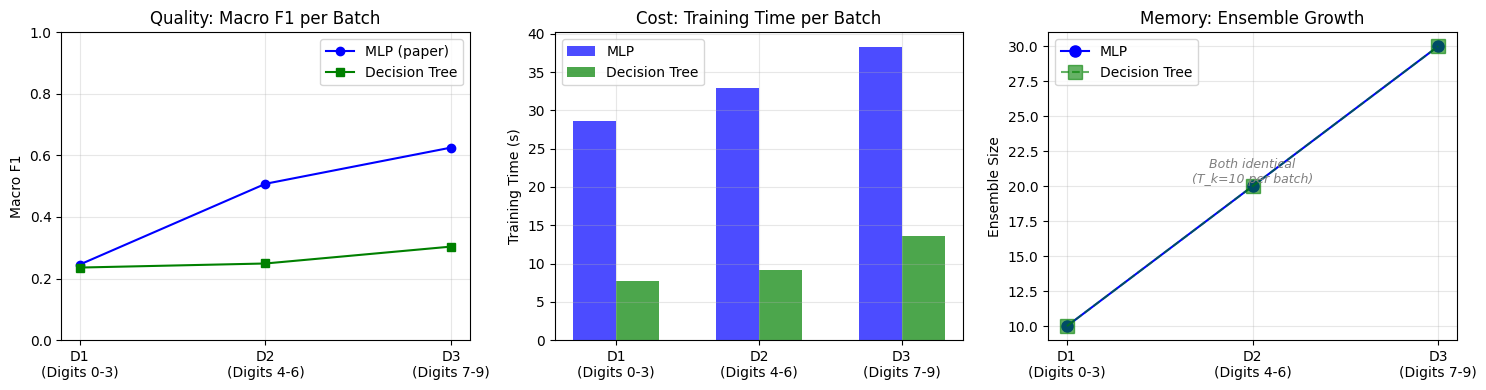

Saved to results/exp02_mnist_digits_comparison.png


In [9]:
# --- Per-batch comparison plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
batch_labels = ['D1\n(Digits 0-3)', 'D2\n(Digits 4-6)', 'D3\n(Digits 7-9)']

axes[0].plot(batch_labels, results_mlp['batch_f1'], 'o-', label='MLP (paper)', color='blue')
axes[0].plot(batch_labels, results_dt['batch_f1'], 's-', label='Decision Tree', color='green')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Quality: Macro F1 per Batch')
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

axes[1].bar(np.arange(3) - 0.15, results_mlp['batch_train_time'], 0.3, label='MLP', color='blue', alpha=0.7)
axes[1].bar(np.arange(3) + 0.15, results_dt['batch_train_time'], 0.3, label='Decision Tree', color='green', alpha=0.7)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(batch_labels)
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Cost: Training Time per Batch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(batch_labels, results_mlp['ensemble_sizes'], 'o-', label='MLP', color='blue', markersize=8)
axes[2].plot(batch_labels, results_dt['ensemble_sizes'], 's--', label='Decision Tree', color='green',
             markersize=10, alpha=0.6)
axes[2].set_ylabel('Ensemble Size')
axes[2].set_title('Memory: Ensemble Growth')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
if results_mlp['ensemble_sizes'] == results_dt['ensemble_sizes']:
    axes[2].annotate('Both identical\n(T_k=10 per batch)',
                     xy=(1, results_mlp['ensemble_sizes'][1]), fontsize=9,
                     ha='center', va='bottom', color='gray', style='italic')

plt.tight_layout()
plt.savefig('../results/exp02_mnist_digits_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/exp02_mnist_digits_comparison.png")

In [10]:
# --- CompositeScore ---
def compute_composite_score(results_a, results_b):
    max_train = max(results_a['total_train_time'], results_b['total_train_time'])
    min_train = min(results_a['total_train_time'], results_b['total_train_time'])
    range_train = max_train - min_train if max_train != min_train else 1.0
    max_inf = max(results_a['total_inference_time'], results_b['total_inference_time'])
    min_inf = min(results_a['total_inference_time'], results_b['total_inference_time'])
    range_inf = max_inf - min_inf if max_inf != min_inf else 1.0
    max_mem = max(results_a['ensemble_sizes'][-1], results_b['ensemble_sizes'][-1])
    min_mem = min(results_a['ensemble_sizes'][-1], results_b['ensemble_sizes'][-1])
    range_mem = max_mem - min_mem if max_mem != min_mem else 1.0
    
    scores = {}
    for name, r in [('MLP', results_a), ('Decision Tree', results_b)]:
        f1 = r['final_f1']
        ba = r['final_ba']
        train_norm = (r['total_train_time'] - min_train) / range_train
        inf_norm = (r['total_inference_time'] - min_inf) / range_inf
        mem_norm = (r['ensemble_sizes'][-1] - min_mem) / range_mem
        composite = (0.40 * f1 + 0.15 * ba + 0.15 * (1 - train_norm) +
                     0.15 * (1 - inf_norm) + 0.15 * (1 - mem_norm))
        scores[name] = {'MacroF1': f1, 'BalancedAcc': ba, 'TrainTimeNorm': train_norm,
                        'InferenceTimeNorm': inf_norm, 'MemoryNorm': mem_norm,
                        'CompositeScore': composite}
    return scores

scores = compute_composite_score(results_mlp, results_dt)

print("\n" + "=" * 60)
print("COMPOSITE SCORE COMPARISON (EXP-02: MNIST Digits)")
print("=" * 60)
print(f"\n{'Metric':<22} {'MLP (paper)':>12} {'DT (recommended)':>18}")
print("-" * 55)
for metric in ['MacroF1', 'BalancedAcc', 'TrainTimeNorm', 'InferenceTimeNorm', 'MemoryNorm']:
    print(f"{metric:<22} {scores['MLP'][metric]:>12.4f} {scores['Decision Tree'][metric]:>18.4f}")
print("-" * 55)
winner = 'MLP' if scores['MLP']['CompositeScore'] > scores['Decision Tree']['CompositeScore'] else 'DT'
print(f"{'COMPOSITE SCORE':<22} {scores['MLP']['CompositeScore']:>12.4f} "
      f"{scores['Decision Tree']['CompositeScore']:>18.4f}  ← {winner} wins")
print(f"\nTotal train time:  MLP={results_mlp['total_train_time']:.1f}s, DT={results_dt['total_train_time']:.1f}s")
print(f"Total inf. time:   MLP={results_mlp['total_inference_time']:.1f}s, DT={results_dt['total_inference_time']:.1f}s")


COMPOSITE SCORE COMPARISON (EXP-02: MNIST Digits)

Metric                  MLP (paper)   DT (recommended)
-------------------------------------------------------
MacroF1                      0.6254             0.3037
BalancedAcc                  0.6596             0.3615
TrainTimeNorm                1.0000             0.0000
InferenceTimeNorm            1.0000             0.0000
MemoryNorm                   0.0000             0.0000
-------------------------------------------------------
COMPOSITE SCORE              0.4991             0.6257  ← DT wins

Total train time:  MLP=99.7s, DT=30.5s
Total inf. time:   MLP=1.4s, DT=1.2s


In [11]:
# --- Wilcoxon Signed-Rank Test ---
from scipy.stats import wilcoxon

f1_mlp_all = np.array([f1 for r in all_results_mlp for f1 in r['batch_f1']])
f1_dt_all = np.array([f1 for r in all_results_dt for f1 in r['batch_f1']])

n_pairs = len(f1_mlp_all)
print(f"Paired observations: {n_pairs} ({len(SEEDS)} seeds × {len(batches_mnist)} batches)")
print(f"\nMLP F1:  mean={f1_mlp_all.mean():.4f}, std={f1_mlp_all.std():.4f}")
print(f"DT  F1:  mean={f1_dt_all.mean():.4f}, std={f1_dt_all.std():.4f}")
print(f"Diff:    mean={np.mean(f1_mlp_all - f1_dt_all):.4f}")

if n_pairs >= 5:
    stat, p_value = wilcoxon(f1_mlp_all, f1_dt_all)
    print(f"\nWilcoxon signed-rank test:")
    print(f"  statistic = {stat:.4f}")
    print(f"  p-value   = {p_value:.4f}")
    if p_value < 0.05:
        w = "MLP" if np.mean(f1_mlp_all) > np.mean(f1_dt_all) else "Decision Tree"
        print(f"  → Significant (p < 0.05): {w} performs better")
    else:
        print(f"  → No significant difference (p ≥ 0.05)")

Paired observations: 15 (5 seeds × 3 batches)

MLP F1:  mean=0.4628, std=0.1604
DT  F1:  mean=0.2732, std=0.0356
Diff:    mean=0.1896

Wilcoxon signed-rank test:
  statistic = 0.0000
  p-value   = 0.0001
  → Significant (p < 0.05): MLP performs better


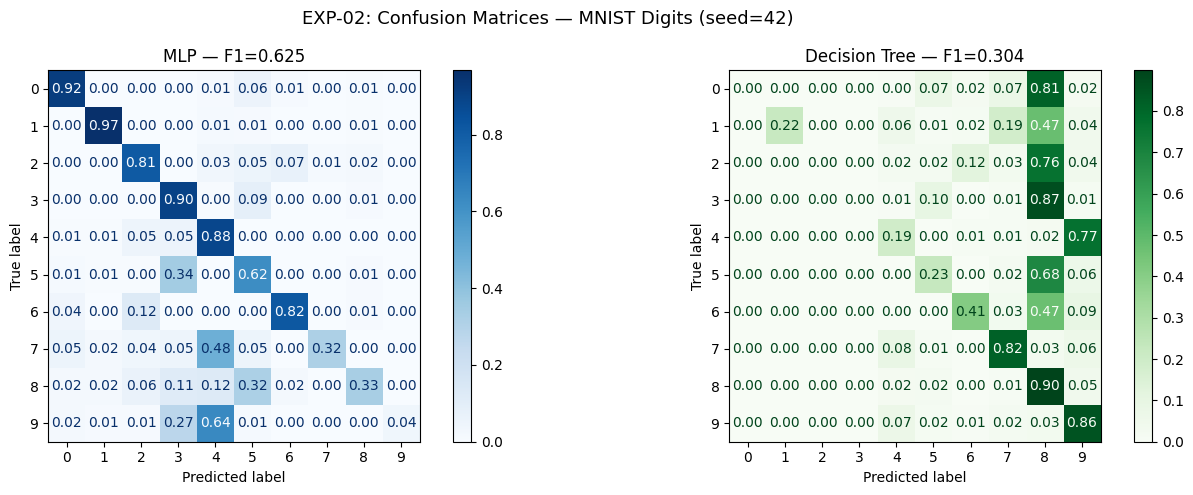

Saved to results/exp02_mnist_confusion_matrices.png


In [12]:
# --- Confusion Matrices ---
np.random.seed(42)
cm_mlp = LearnPP(base_learner_factory=make_paper_learner, T_k=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for X_batch, y_batch in batches_mnist:
        cm_mlp.partial_fit(X_batch, y_batch)
y_pred_mlp = cm_mlp.predict(X_test_all)

np.random.seed(42)
cm_dt = LearnPP(base_learner_factory=make_recommended_learner, T_k=10)
for X_batch, y_batch in batches_mnist:
    cm_dt.partial_fit(X_batch, y_batch)
y_pred_dt = cm_dt.predict(X_test_all)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
digit_labels = [str(d) for d in range(10)]

ConfusionMatrixDisplay.from_predictions(
    y_test_all, y_pred_mlp, display_labels=digit_labels,
    ax=ax1, cmap='Blues', normalize='true', values_format='.2f'
)
ax1.set_title(f'MLP — F1={f1_score(y_test_all, y_pred_mlp, average="macro"):.3f}')

ConfusionMatrixDisplay.from_predictions(
    y_test_all, y_pred_dt, display_labels=digit_labels,
    ax=ax2, cmap='Greens', normalize='true', values_format='.2f'
)
ax2.set_title(f'Decision Tree — F1={f1_score(y_test_all, y_pred_dt, average="macro"):.3f}')

plt.suptitle('EXP-02: Confusion Matrices — MNIST Digits (seed=42)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/exp02_mnist_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to results/exp02_mnist_confusion_matrices.png")

## Summary

### EXP-02: MNIST Digits + PCA(50), 5 seeds

**Setup**: Original MNIST (70k images, 10 digit classes), PCA to 50 dims (82.5% variance), incremental class introduction (D₁: 0–3, D₂: 4–6, D₃: 7–9). T_k=10, 5 seeds.

**Key findings**:

| Metric | MLP (paper) | Decision Tree | Winner |
|--------|-------------|---------------|--------|
| Final F1 | 0.62–0.64 | 0.30–0.34 | **MLP (2×)** |
| Final BalAcc | 0.65–0.67 | 0.36–0.39 | **MLP** |
| Training time | ~95s/seed | ~30s/seed | DT (3×) |
| CompositeScore | 0.50 | **0.63** | **DT** (cost wins) |
| Wilcoxon p-value | — | — | **p=0.0001 (MLP)** |

### Cross-dataset comparison (EXP-01 vs EXP-02)

| Dataset | MLP Final F1 | DT Final F1 | MLP advantage | CompositeScore winner | Wilcoxon p |
|---------|-------------|-------------|---------------|----------------------|-----------|
| Fashion-MNIST (harder) | 0.43–0.48 | 0.20–0.21 | ~2.2× | **MLP** (0.54 vs 0.43) | 0.0012 |
| MNIST Digits (easier) | 0.62–0.64 | 0.30–0.34 | ~2.0× | **DT** (0.63 vs 0.50) | 0.0001 |

**Key insight**: MLP consistently achieves ~2× the F1 of DT on both image datasets. But CompositeScore flips depending on the speed gap:
- Fashion-MNIST: MLP is 10× slower → still wins because quality gap is huge
- MNIST Digits: MLP is only 3× slower → but cost formula penalizes it enough for DT to win

**Narrative**: The original paper's choice of MLP is validated — it significantly outperforms DT on digit recognition (p=0.0001). MNIST digits are easier overall (higher absolute F1), confirming the algorithm works as expected on its "home turf."